<!--
Copyright (c) Meta Platforms, Inc. and affiliates.
All rights reserved.

This source code is licensed under the CC-BY-NC-4.0 license found in the
LICENSE file in the root directory of this source tree.
-->

In [1]:
import os, sys
from pathlib import Path
REPO = Path(os.environ.get('LONG_AUDIO_REPO', Path.cwd())).resolve()
if REPO.name == 'notebooks':
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import json
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Rebuild the font cache from whatever is actually available
sns.set_theme()  # Applies seaborn's default aesthetic
# fm._load_fontmanager(try_read_cache=False)

# mpl.rcParams['font.family'] = 'sans-serif'
# mpl.rcParams['font.sans-serif'] = ['DroidSans']


RUN_TS = "desc-v4-20260715T160821Z"
DATA_DIR = REPO / "notebooks/data" / RUN_TS
print("DATA_DIR:", DATA_DIR.relative_to(REPO), "(exists:", DATA_DIR.exists(), ")")

# ---- Pretty display names + fixed axis orderings (2026-07-20) --------
TEXT_LLM_DISPLAY = {
    "k2-v2": "K2-V2",
    "olmo3.1-32b": "Olmo 3.1",
    "qwen2.5-72b": "Qwen 2.5",
    "llama3.3-70b": "Llama 3.3",
    "qwen3-32b": "Qwen 3",
    "gemma4-31b": "Gemma 4",
    "gemini": "Gemini 3.5",  # Flash
    "luna": "GPT 5.6",  # Luna
}
TEXT_LLMS_ORDERED = [
    "k2-v2",
    "olmo3.1-32b",
    "qwen2.5-72b",
    "llama3.3-70b",
    "qwen3-32b",
    "gemma4-31b",
    "gemini",
    "luna",
]

CASCA_DISPLAY = {
    "enclap": "EnCLAP",
    "msclap-cap": "MSCLAP",
    "qwen2.5-omni": "Q2.5",
    "qwen3-omni": "Q3",
    "qwen3-omni-captioner": "Q3 Cap.",
    "af3-hf": "AF3",
}
CASCA_ORDERED = list(CASCA_DISPLAY.keys())

TEXT_LLM_ROWS = [TEXT_LLM_DISPLAY[t] for t in TEXT_LLMS_ORDERED]
CASCA_COLS = [CASCA_DISPLAY[a] for a in CASCA_ORDERED]

DATASETS = ["ego4d", "egolife", "sins"]


def _safe_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return float("nan")


def _normalize_sins_scores(sc):
    if not isinstance(sc, dict):
        return {}
    v_bf1 = _safe_float(sc.get("boundary_f1", {}).get("f1"))
    v_facc = _safe_float(sc.get("frame_level_accuracy", {}).get("overall_accuracy"))
    v_ef1 = _safe_float(sc.get("event_based_f1", {}).get("f1"))
    v_eer = _safe_float(sc.get("event_error_rate", {}).get("error_rate"))
    return {
        "micro": {"boundary_f1": v_bf1, "frame_accuracy": v_facc, "event_f1": v_ef1},
        "macro": {
            "boundary_f1": v_bf1,
            "frame_accuracy": v_facc,
            "event_f1": v_ef1,
            "event_error_rate": v_eer,
        },
    }


SEG_MICRO = lambda key: (lambda d: _safe_float(d.get("micro", {}).get(key)))
SEG_MACRO = lambda key: (lambda d: _safe_float(d.get("macro", {}).get(key)))


def _desc_ratio(path):
    def _f(cell_dict):
        node = cell_dict
        for k in path:
            if not isinstance(node, dict) or k not in node:
                return float("nan")
            node = node[k]
        return _safe_float(node)

    return _f


METRICS = [
    # short_key,   family, reader,                                             lower_is_better, full_name
    ("bF1", "seg", SEG_MICRO("boundary_f1"), False, "Boundary F1 (micro)"),
    ("facc", "seg", SEG_MICRO("frame_accuracy"), False, "Frame Accuracy (micro)"),
    ("eF1", "seg", SEG_MICRO("event_f1"), False, "Event F1 (micro)"),
    (
        "EER",
        "seg",
        SEG_MACRO("event_error_rate"),
        True,
        "Event Error Rate (macro; micro not reported)",
    ),
    (
        "recall",
        "desc",
        _desc_ratio(["summary_recall", "ratio"]),
        False,
        "Summary Recall",
    ),
    (
        "sprec",
        "desc",
        _desc_ratio(["summary_precision", "ratio"]),
        False,
        "Summary Precision",
    ),
    (
        "mrecall",
        "desc",
        _desc_ratio(["moments_recall", "ratio"]),
        False,
        "Moments Recall",
    ),
    (
        "redundant",
        "desc",
        _desc_ratio(["self_consistency", "pct_redundant"]),
        True,
        "Self-Consistency %-Redundant (micro)",
    ),
]
SEG_METRICS = [m for m in METRICS if m[1] == "seg"]
DESC_METRICS = [m for m in METRICS if m[1] == "desc"]

# Load every seg + desc + sins-summary json into a tidy long-form DataFrame.
# columns: dataset, text_llm, cascA, metric, value

CASCB_RE = re.compile(
    r"^cascB_(?P<tm>[^/]+)/cascA_(?P<arm>[^/]+)/(?P<ds>ego4d|egolife|sins)$"
)
_JSON_DECODER = json.JSONDecoder()


def _load_json_lax(p: Path):
    txt = p.read_text().lstrip()
    obj, _ = _JSON_DECODER.raw_decode(txt)
    return obj


def _iter_seg_ego4d_egolife():
    for p in DATA_DIR.glob("cascB_*/cascA_*/*/eval_segmentation.json"):
        m = CASCB_RE.match(str(p.parent.relative_to(DATA_DIR)))
        if not m:
            continue
        tm, arm, ds = m.group("tm"), m.group("arm"), m.group("ds")
        if tm.endswith("_ft") or arm.endswith("_ft"):
            continue
        yield tm, arm, ds, _load_json_lax(p)


def _iter_seg_sins():
    for p in DATA_DIR.glob("cascB_*/cascA_*/sins/summary.json"):
        m = CASCB_RE.match(str(p.parent.relative_to(DATA_DIR)))
        if not m:
            continue
        tm, arm, ds = m.group("tm"), m.group("arm"), m.group("ds")
        if tm.endswith("_ft") or arm.endswith("_ft"):
            continue
        scores = _load_json_lax(p).get("eval_scores")
        if scores is None:
            continue
        yield tm, arm, ds, _normalize_sins_scores(scores)


def _iter_desc_cells():
    for p in DATA_DIR.glob(
        "eval_descriptions/*/cascB_*__cascA_*/eval_descriptions.json"
    ):
        ds = p.parent.parent.name
        cell_name = p.parent.name
        try:
            left, arm = cell_name.split("__cascA_")
            tm = left[len("cascB_") :]
        except ValueError:
            continue
        if tm.endswith("_ft") or arm.endswith("_ft"):
            continue
        cell_dict = _load_json_lax(p).get("cells", {}).get(cell_name, {})
        yield tm, arm, ds, cell_dict


rows = []
for iter_fn, family in [
    (_iter_seg_ego4d_egolife, "seg"),
    (_iter_seg_sins, "seg"),
    (_iter_desc_cells, "desc"),
]:
    for tm, arm, ds, blob in iter_fn():
        for short, fam, reader, _lo, _full in METRICS:
            if fam != family:
                continue
            rows.append(
                dict(
                    dataset=ds, text_llm=tm, cascA=arm, metric=short, value=reader(blob)
                )
            )

df = pd.DataFrame(rows)

df = df[df.cascA.isin(CASCA_ORDERED)].reindex()


print("rows:", len(df))
print(
    "unique cells per dataset:",
    df[["dataset", "text_llm", "cascA"]]
    .drop_duplicates()
    .groupby("dataset")
    .size()
    .to_dict(),
)
print("metrics:", sorted(df.metric.unique()))
print("text_llms:", sorted(df.text_llm.unique()))
print("cascA arms:", sorted(df.cascA.unique()))

DATA_DIR: notebooks/data/desc-v4-20260715T160821Z (exists: True )


rows: 960
unique cells per dataset: {'ego4d': 48, 'egolife': 48, 'sins': 48}
metrics: ['EER', 'bF1', 'eF1', 'facc', 'mrecall', 'recall', 'redundant', 'sprec']
text_llms: ['gemini', 'gemma4-31b', 'k2-v2', 'llama3.3-70b', 'luna', 'olmo3.1-32b', 'qwen2.5-72b', 'qwen3-32b']
cascA arms: ['af3-hf', 'enclap', 'msclap-cap', 'qwen2.5-omni', 'qwen3-omni', 'qwen3-omni-captioner']


In [2]:
# --- Shared helpers for the overall tables (reused by the captioner cell below) ---
def _mean_metric(axis, ds, mkey):
    """Mean of `mkey` at (ds, axis) across the other axis. Series indexed by axis values."""
    sub = df[(df.dataset == ds) & (df.metric == mkey)]
    return sub.groupby(axis)['value'].mean()

def _mean_per_cell_f1(axis, ds):
    """Compute per-cell F1 (from that cell's R and P), THEN average across the other axis.
    Note: this F1 column is NOT algebraically 2 * R_col * P_col / (R_col + P_col),
    because R_col and P_col are themselves averages. Kwanghee wants per-cell F1 first,
    then averaged — the definition used here."""
    other = 'cascA' if axis == 'text_llm' else 'text_llm'
    R = (df[(df.dataset == ds) & (df.metric == 'recall')]
           .set_index([axis, other])['value'])
    P = (df[(df.dataset == ds) & (df.metric == 'sprec')]
           .set_index([axis, other])['value'])
    idx = R.index.union(P.index)
    R = R.reindex(idx); P = P.reindex(idx)
    denom = (R + P).replace(0, np.nan)
    f1_per_cell = 2 * R * P / denom
    return f1_per_cell.groupby(level=axis).mean()

def _reindex_display(tab, order, display_map):
    tab = tab.reindex(order)
    tab.index = [display_map[t] for t in tab.index]
    return tab

def build_ego4d_table(axis, order, display_map):
    ds = 'ego4d'
    cols = pd.MultiIndex.from_tuples([
        ('Seg (Ego4D)',         'bF1'),
        ('Seg (Ego4D)',         'evER↓'),
        ('Seg (Ego4D)',         'fAcc'),
        ('Desc R/P/F1 (Ego4D)', 'R'),
        ('Desc R/P/F1 (Ego4D)', 'P'),
        ('Desc R/P/F1 (Ego4D)', 'F1'),
        ('Desc extras (Ego4D)', 'Hitrate'),
        ('Desc extras (Ego4D)', 'rddc↓'),
    ])
    data = [
        _mean_metric(axis, ds, 'bF1'),
        _mean_metric(axis, ds, 'EER'),
        _mean_metric(axis, ds, 'facc'),
        _mean_metric(axis, ds, 'recall'),
        _mean_metric(axis, ds, 'sprec'),
        _mean_per_cell_f1(axis, ds),
        _mean_metric(axis, ds, 'mrecall'),
        _mean_metric(axis, ds, 'redundant'),
    ]
    tab = pd.DataFrame({c: s for c, s in zip(cols, data)})
    tab.columns = cols
    return _reindex_display(tab, order, display_map)

def build_sins_egolife_table(axis, order, display_map):
    cols = pd.MultiIndex.from_tuples([
        ('Seg (SINS)',     'bF1'),
        ('Seg (SINS)',     'evER↓'),
        ('Seg (SINS)',     'fAcc'),
        ('Seg (EgoLife)',  'bF1'),
        ('Seg (EgoLife)',  'evER↓'),
        ('Seg (EgoLife)',  'fAcc'),
        ('Desc (EgoLife)', 'R'),
        ('Desc (EgoLife)', 'P'),
        ('Desc (EgoLife)', 'F1'),
    ])
    data = [
        _mean_metric(axis, 'sins',    'bF1'),
        _mean_metric(axis, 'sins',    'EER'),
        _mean_metric(axis, 'sins',    'facc'),
        _mean_metric(axis, 'egolife', 'bF1'),
        _mean_metric(axis, 'egolife', 'EER'),
        _mean_metric(axis, 'egolife', 'facc'),
        _mean_metric(axis, 'egolife', 'recall'),
        _mean_metric(axis, 'egolife', 'sprec'),
        _mean_per_cell_f1(axis, 'egolife'),
    ]
    tab = pd.DataFrame({c: s for c, s in zip(cols, data)})
    tab.columns = cols
    return _reindex_display(tab, order, display_map)

def style_overall(tab, caption=None):
    sty = tab.style.format('{:.3f}', na_rep='—')
    for col in tab.columns:
        lower_better = str(col[1]).endswith('↓')
        cmap = 'viridis_r' if lower_better else 'viridis'
        sty = sty.background_gradient(cmap=cmap, subset=[col])
    if caption:
        sty = sty.set_caption(caption)
    return sty

from IPython.display import display, Markdown

t_llm_ego = build_ego4d_table('text_llm', TEXT_LLMS_ORDERED, TEXT_LLM_DISPLAY)
t_llm_se  = build_sins_egolife_table('text_llm', TEXT_LLMS_ORDERED, TEXT_LLM_DISPLAY)

print('=== Text-LLM · Ego4D ===')
print(t_llm_ego.round(3).to_string(na_rep='—'))
print()
print('=== Text-LLM · SINS + EgoLife ===')
print(t_llm_se.round(3).to_string(na_rep='—'))

display(Markdown('#### Text-LLM · Ego4D'))
display(style_overall(t_llm_ego, 'Mean across cascade Stage-A arms on Ego4D.'))
display(Markdown('#### Text-LLM · SINS + EgoLife'))
display(style_overall(t_llm_se, 'Mean across cascade Stage-A arms on SINS (seg) + EgoLife (seg + desc).'))

=== Text-LLM · Ego4D ===
           Seg (Ego4D)               Desc R/P/F1 (Ego4D)               Desc extras (Ego4D)       
                   bF1  evER↓   fAcc                   R      P     F1             Hitrate  rddc↓
K2-V2            0.404  1.773  0.117               0.107  0.106  0.101               0.061  0.223
Olmo 3.1         0.496  3.685  0.179               0.221  0.157  0.184               0.139  0.331
Qwen 2.5         0.492  3.361  0.367               0.270  0.141  0.183               0.172  0.282
Llama 3.3        0.500  4.565  0.363               0.272  0.151  0.193               0.162  0.351
Qwen 3           0.481  3.472  0.308               0.271  0.148  0.190               0.162  0.328
Gemma 4          0.500  3.511  0.370               0.271  0.189  0.219               0.166  0.293
Gemini 3.5       0.492  3.096  0.373               0.271  0.156  0.197               0.175  0.317
GPT 5.6          0.499  3.691  0.361               0.289  0.163  0.205               0.180  0

#### Text-LLM · Ego4D

#### Text-LLM · SINS + EgoLife

In [3]:
# --- Captioner axis: 2 tables (reuses helpers from the text-LLM cell above) ---
t_cap_ego = build_ego4d_table('cascA', CASCA_ORDERED, CASCA_DISPLAY)
t_cap_se  = build_sins_egolife_table('cascA', CASCA_ORDERED, CASCA_DISPLAY)

print('=== Captioner · Ego4D ===')
print(t_cap_ego.round(3).to_string(na_rep='—'))
print()
print('=== Captioner · SINS + EgoLife ===')
print(t_cap_se.round(3).to_string(na_rep='—'))

display(Markdown('#### Captioner · Ego4D'))
display(style_overall(t_cap_ego, 'Mean across cascade text LLMs on Ego4D.'))
display(Markdown('#### Captioner · SINS + EgoLife'))
display(style_overall(t_cap_se, 'Mean across cascade text LLMs on SINS (seg) + EgoLife (seg + desc).'))

=== Captioner · Ego4D ===
        Seg (Ego4D)               Desc R/P/F1 (Ego4D)               Desc extras (Ego4D)       
                bF1  evER↓   fAcc                   R      P     F1             Hitrate  rddc↓
EnCLAP        0.480  2.528  0.320               0.222  0.164  0.188               0.151  0.349
MSCLAP        0.487  2.618  0.287               0.219  0.156  0.181               0.142  0.308
Q2.5          0.491  3.519  0.295               0.240  0.146  0.181               0.150  0.282
Q3            0.502  4.444  0.313               0.283  0.140  0.186               0.161  0.282
Q3 Cap.       0.450  4.499  0.283               0.271  0.136  0.173               0.144  0.294
AF3           0.488  2.757  0.330               0.245  0.166  0.197               0.165  0.320

=== Captioner · SINS + EgoLife ===
        Seg (SINS)               Seg (EgoLife)               Desc (EgoLife)              
               bF1  evER↓   fAcc           bF1  evER↓   fAcc              R      P     F

#### Captioner · Ego4D

#### Captioner · SINS + EgoLife

In [4]:
# Topline comparison — matches "Overall table · audio-captioner" structure:
# two tables (Ego4D | SINS + EgoLife) with MultiIndex column headers, per-cell
# data from specific systems (no cascA averaging).
_DEC = json.JSONDecoder()
def _load(p):
    return _DEC.raw_decode(p.read_text().lstrip())[0]

SYSTEM_ROWS = [
    ('cascB_gemini/cascA_af3-hf',       'Cascaded Gemini'),
    ('cascB_luna/cascA_af3-hf',         'Cascaded GPT'),
    ('cascB_gemma4-31b/cascA_af3-hf',   'Cascaded Gemma'),
    ('cascB_gemma4-31b_ft/cascA_af3-hf',     'Cascaded Gemma 4 (SFT)'),
    ('e2e_gemini',                       'E2E Gemini'),
    ('e2e_qwen3-omni',                   'E2E Qwen 3-Omni'),
    ('e2e_qwen3-omni_ft',                     'E2E Qwen 3-Omni (SFT)'),
    ('e2e_qwen2.5-omni',                 'E2E Qwen 2.5-Omni'),
    ('e2e_af3-hf',                       'E2E AF3-HF'),
    ('__human__',                        'Human'),
]

def _cell_paths(source_key, ds):
    # (seg_json_path, desc_cell_name) for a system + dataset.
    if source_key.startswith('cascB_'):
        tm = source_key.split('/')[0].removeprefix('cascB_')
        arm = source_key.split('/')[1].removeprefix('cascA_')
        seg_p = DATA_DIR / source_key / ds / ('summary.json' if ds == 'sins' else 'eval_segmentation.json')
        desc_name = f'cascB_{tm}__cascA_{arm}'
    else:
        seg_p = DATA_DIR / source_key / ds / ('summary.json' if ds == 'sins' else 'eval_segmentation.json')
        desc_name = source_key
    return seg_p, desc_name

def _seg_scores(source_key, ds):
    seg_p, _ = _cell_paths(source_key, ds)
    if not seg_p.exists(): return None
    j = _load(seg_p)
    if ds == 'sins':
        return _normalize_sins_scores(j.get('eval_scores', {}))
    return j

def _desc_cell(source_key, ds):
    _, desc_name = _cell_paths(source_key, ds)
    p = DATA_DIR / 'eval_descriptions' / ds / desc_name / 'eval_descriptions.json'
    if not p.exists(): return None
    return _load(p).get('cells', {}).get(desc_name, {})

def _human_seg_scores(ds):
    if ds == 'sins': return None
    for p in DATA_DIR.glob(f'cascB_*/cascA_*/{ds}/eval_segmentation.json'):
        j = _load(p)
        hb = j.get('human_baseline')
        if hb: return hb
    return None

def _human_desc_cell(ds):
    if ds == 'sins': return None
    for p in DATA_DIR.glob(f'eval_descriptions/{ds}/*/eval_descriptions.json'):
        j = _load(p)
        hb = j.get('human_baseline')
        if hb: return hb
    return None

def _row_scores(source_key, ds):
    """Return (seg_blob, desc_blob) for one system on one dataset."""
    if source_key == '__human__':
        return _human_seg_scores(ds), _human_desc_cell(ds)
    return _seg_scores(source_key, ds), _desc_cell(source_key, ds)

def _read_metric(short, seg, desc):
    """Look up a metric shortcode from METRICS."""
    for s, fam, reader, _lo, _full in METRICS:
        if s == short:
            blob = seg if fam == 'seg' else desc
            return reader(blob) if blob is not None else float('nan')
    return float('nan')

def _row_desc_f1(desc):
    """Per-cell desc F1 from R and P — matches captioner-table convention
    (per-cell F1, NOT F1 of averaged R and P)."""
    if desc is None: return float('nan')
    r = _read_metric('recall', None, desc)
    p = _read_metric('sprec',  None, desc)
    if not (r == r and p == p) or (r + p) == 0:
        return float('nan')
    return 2 * r * p / (r + p)

def build_topline_ego4d():
    ds = 'ego4d'
    cols = pd.MultiIndex.from_tuples([
        ('Seg (Ego4D)',         'bF1'),
        ('Seg (Ego4D)',         'evER↓'),
        ('Seg (Ego4D)',         'fAcc'),
        ('Desc R/P/F1 (Ego4D)', 'R'),
        ('Desc R/P/F1 (Ego4D)', 'P'),
        ('Desc R/P/F1 (Ego4D)', 'F1'),
        ('Desc extras (Ego4D)', 'Hitrate'),
        ('Desc extras (Ego4D)', 'rddc↓'),
    ])
    rows_data, row_labels = [], []
    for source_key, display in SYSTEM_ROWS:
        seg, desc = _row_scores(source_key, ds)
        rows_data.append([
            _read_metric('bF1',       seg, desc),
            _read_metric('EER',       seg, desc),
            _read_metric('facc',      seg, desc),
            _read_metric('recall',    seg, desc),
            _read_metric('sprec',     seg, desc),
            _row_desc_f1(desc),
            _read_metric('mrecall',   seg, desc),
            _read_metric('redundant', seg, desc),
        ])
        row_labels.append(display)
    tab = pd.DataFrame(rows_data, index=row_labels, columns=cols)
    tab.index.name = 'System'
    return tab

def build_topline_sins_egolife():
    cols = pd.MultiIndex.from_tuples([
        ('Seg (SINS)',     'bF1'),
        ('Seg (SINS)',     'evER↓'),
        ('Seg (SINS)',     'fAcc'),
        ('Seg (EgoLife)',  'bF1'),
        ('Seg (EgoLife)',  'evER↓'),
        ('Seg (EgoLife)',  'fAcc'),
        ('Desc (EgoLife)', 'R'),
        ('Desc (EgoLife)', 'P'),
        ('Desc (EgoLife)', 'F1'),
    ])
    rows_data, row_labels = [], []
    for source_key, display in SYSTEM_ROWS:
        seg_s, desc_s = _row_scores(source_key, 'sins')
        seg_e, desc_e = _row_scores(source_key, 'egolife')
        rows_data.append([
            _read_metric('bF1',    seg_s, desc_s),
            _read_metric('EER',    seg_s, desc_s),
            _read_metric('facc',   seg_s, desc_s),
            _read_metric('bF1',    seg_e, desc_e),
            _read_metric('EER',    seg_e, desc_e),
            _read_metric('facc',   seg_e, desc_e),
            _read_metric('recall', seg_e, desc_e),
            _read_metric('sprec',  seg_e, desc_e),
            _row_desc_f1(desc_e),
        ])
        row_labels.append(display)
    tab = pd.DataFrame(rows_data, index=row_labels, columns=cols)
    tab.index.name = 'System'
    return tab

from IPython.display import display, Markdown

t_top_ego = build_topline_ego4d()
t_top_se  = build_topline_sins_egolife()

print('=== Topline · Ego4D ===')
print(t_top_ego.round(3).to_string(na_rep='—'))
print()
print('=== Topline · SINS + EgoLife ===')
print(t_top_se.round(3).to_string(na_rep='—'))

display(Markdown('#### Topline · Ego4D'))
display(style_overall(t_top_ego, 'Best cascades (Gemini/Gemma/Luna + AF3) vs E2E arms and human baseline on Ego4D.'))
display(Markdown('#### Topline · SINS + EgoLife'))
display(style_overall(t_top_se, 'Same systems on SINS (seg) + EgoLife (seg + desc). Human is present only on EgoLife (no SINS GT).'))


=== Topline · Ego4D ===
                       Seg (Ego4D)               Desc R/P/F1 (Ego4D)               Desc extras (Ego4D)       
                               bF1  evER↓   fAcc                   R      P     F1             Hitrate  rddc↓
System                                                                                                       
Cascaded Gemini              0.493  2.319  0.397               0.276  0.175  0.215               0.198  0.340
Cascaded GPT                 0.500  2.863  0.383               0.273  0.182  0.218               0.191  0.340
Cascaded Gemma               0.508  2.608  0.398               0.262  0.218  0.238               0.160  0.304
Cascaded Gemma 4 (SFT)       0.247  0.785  0.520               0.316  0.403  0.355               0.180  0.207
E2E Gemini                   0.437  1.357  0.445               0.271  0.209  0.236               0.214  0.289
E2E Qwen 3-Omni              0.349  1.344  0.413               0.214  0.161  0.183              

#### Topline · Ego4D

#### Topline · SINS + EgoLife

In [5]:
# SFT vs baseline — matches "Overall table · audio-captioner" structure:
# two tables (Ego4D | SINS + EgoLife) with MultiIndex column headers, per-cell
# data from specific systems (no cascA averaging). Rows: SYSTEM_ROWS_SFT.
SYSTEM_ROWS_SFT = [
    # Baselines
    ('cascB_gemini/cascA_af3-hf',            'Cascaded Gemini + AF3'),
    ('cascB_luna/cascA_af3-hf',              'Cascaded GPT + AF3'),
    ('cascB_gemma4-31b/cascA_af3-hf',        'Cascaded Gemma 4 + AF3'),
    ('cascB_gemma4-31b_ft/cascA_af3-hf',     'Cascaded Gemma 4 (SFT) + AF3'),
    ('e2e_gemini',                            'E2E Gemini'),
    ('e2e_qwen3-omni',                        'E2E Qwen 3-Omni'),
    ('e2e_qwen3-omni_ft',                     'E2E Qwen 3-Omni (SFT)'),
    # Fine-tuned
    # ('cascB_qwen3-32b_ft/cascA_af3-hf',      'Cascaded Qwen 3-32B (SFT) + AF3'),
    # Human (ego4d only; NaN on SINS/EgoLife)
    ('__human__',                             'Human'),
]


def build_sft_ego4d():
    """Mirror of build_topline_ego4d (cell 24) but for SYSTEM_ROWS_SFT."""
    ds = 'ego4d'
    cols = pd.MultiIndex.from_tuples([
        ('Seg (Ego4D)',         'bF1'),
        ('Seg (Ego4D)',         'evER↓'),
        ('Seg (Ego4D)',         'fAcc'),
        ('Desc R/P/F1 (Ego4D)', 'R'),
        ('Desc R/P/F1 (Ego4D)', 'P'),
        ('Desc R/P/F1 (Ego4D)', 'F1'),
        ('Desc extras (Ego4D)', 'Hitrate'),
        ('Desc extras (Ego4D)', 'rddc↓'),
    ])
    rows_data, row_labels = [], []
    for source_key, display in SYSTEM_ROWS_SFT:
        seg, desc = _row_scores(source_key, ds)
        rows_data.append([
            _read_metric('bF1',       seg, desc),
            _read_metric('EER',       seg, desc),
            _read_metric('facc',      seg, desc),
            _read_metric('recall',    seg, desc),
            _read_metric('sprec',     seg, desc),
            _row_desc_f1(desc),
            _read_metric('mrecall',   seg, desc),
            _read_metric('redundant', seg, desc),
        ])
        row_labels.append(display)
    tab = pd.DataFrame(rows_data, index=row_labels, columns=cols)
    tab.index.name = 'System'
    return tab


def build_sft_sins_egolife():
    """Mirror of build_topline_sins_egolife (cell 24) but for SYSTEM_ROWS_SFT."""
    cols = pd.MultiIndex.from_tuples([
        ('Seg (SINS)',     'bF1'),
        ('Seg (SINS)',     'evER↓'),
        ('Seg (SINS)',     'fAcc'),
        ('Seg (EgoLife)',  'bF1'),
        ('Seg (EgoLife)',  'evER↓'),
        ('Seg (EgoLife)',  'fAcc'),
        ('Desc (EgoLife)', 'R'),
        ('Desc (EgoLife)', 'P'),
        ('Desc (EgoLife)', 'F1'),
    ])
    rows_data, row_labels = [], []
    for source_key, display in SYSTEM_ROWS_SFT:
        seg_s, desc_s = _row_scores(source_key, 'sins')
        seg_e, desc_e = _row_scores(source_key, 'egolife')
        rows_data.append([
            _read_metric('bF1',    seg_s, desc_s),
            _read_metric('EER',    seg_s, desc_s),
            _read_metric('facc',   seg_s, desc_s),
            _read_metric('bF1',    seg_e, desc_e),
            _read_metric('EER',    seg_e, desc_e),
            _read_metric('facc',   seg_e, desc_e),
            _read_metric('recall', seg_e, desc_e),
            _read_metric('sprec',  seg_e, desc_e),
            _row_desc_f1(desc_e),
        ])
        row_labels.append(display)
    tab = pd.DataFrame(rows_data, index=row_labels, columns=cols)
    tab.index.name = 'System'
    return tab


from IPython.display import display, Markdown

t_sft_ego = build_sft_ego4d()
t_sft_se  = build_sft_sins_egolife()

print('=== SFT vs baseline · Ego4D ===')
print(t_sft_ego.round(3).to_string(na_rep='—'))
print()
print('=== SFT vs baseline · SINS + EgoLife ===')
print(t_sft_se.round(3).to_string(na_rep='—'))

display(Markdown('#### SFT vs baseline · Ego4D'))
display(style_overall(t_sft_ego, 'Baselines + SFT variants on Ego4D. Human is inter-annotator baseline.'))
display(Markdown('#### SFT vs baseline · SINS + EgoLife'))
display(style_overall(t_sft_se, 'Same systems on SINS (seg) + EgoLife (seg + desc). Human row is all-NaN (no SINS GT; no EgoLife human baseline).'))


=== SFT vs baseline · Ego4D ===
                             Seg (Ego4D)               Desc R/P/F1 (Ego4D)               Desc extras (Ego4D)       
                                     bF1  evER↓   fAcc                   R      P     F1             Hitrate  rddc↓
System                                                                                                             
Cascaded Gemini + AF3              0.493  2.319  0.397               0.276  0.175  0.215               0.198  0.340
Cascaded GPT + AF3                 0.500  2.863  0.383               0.273  0.182  0.218               0.191  0.340
Cascaded Gemma 4 + AF3             0.508  2.608  0.398               0.262  0.218  0.238               0.160  0.304
Cascaded Gemma 4 (SFT) + AF3       0.247  0.785  0.520               0.316  0.403  0.355               0.180  0.207
E2E Gemini                         0.437  1.357  0.445               0.271  0.209  0.236               0.214  0.289
E2E Qwen 3-Omni                    0.349

#### SFT vs baseline · Ego4D

#### SFT vs baseline · SINS + EgoLife

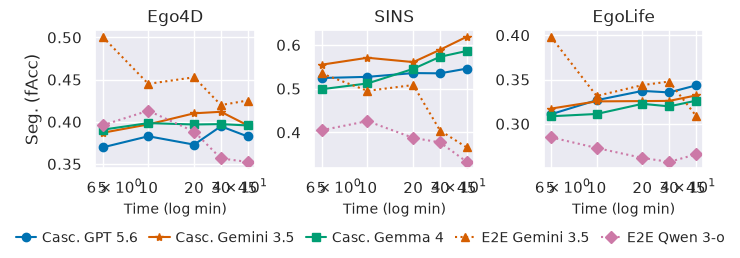

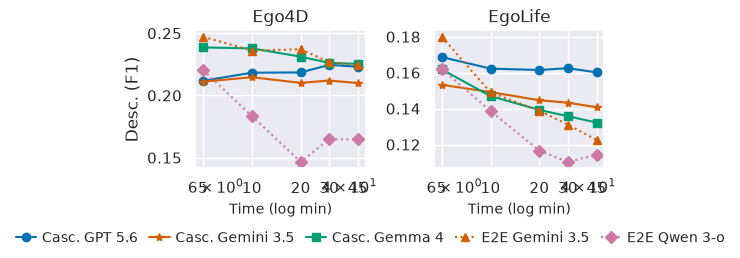

In [6]:
# Window-size ablation — line plots per (dataset × metric)
import matplotlib.pyplot as plt
import seaborn as sns


# fm._load_fontmanager(try_read_cache=False)
sns.set_theme()  # Applies seaborn's default aesthetic
plt.style.use("seaborn-v0_8-colorblind")


CHUNK_MIN_ORDER = [
    # "2.5min",
    "5min",
    "10min",
    "20min",
    "30min",
    "45min",
]
CHUNK_MIN_X = [
    # 2.5,
    5,
    10,
    20,
    30,
    45,
]

# Models we want to line-up across chunk sizes (matches window loader's cell keys).
WIN_MODEL_DISPLAY = {
    "cascB_luna/cascA_af3-hf": "Casc. GPT 5.6",
    "cascB_gemini/cascA_af3-hf": "Casc. Gemini 3.5",
    "cascB_gemma4-31b/cascA_af3-hf": "Casc. Gemma 4",
    # 'cascB_gemma4-31b_ft/cascA_af3-hf': 'Cascade: Gemma-4 FT + AF3',
    "e2e_gemini": "E2E Gemini 3.5",
    "e2e_qwen3-omni": "E2E Qwen 3-o",
    # 'e2e_qwen3-omni_ft':              'E2E: Qwen3-Omni FT',
}
WIN_MODEL_KEYS = list(WIN_MODEL_DISPLAY.keys())
# Distinct colors + line styles for readability
WIN_MODEL_STYLE = {
    "cascB_luna/cascA_af3-hf": dict(color="C0", ls="-", marker="o"),
    "cascB_gemini/cascA_af3-hf": dict(color="C2", ls="-", marker="*"),
    "cascB_gemma4-31b/cascA_af3-hf": dict(color="C1", ls="-", marker="s"),
    "cascB_gemma4-31b_ft/cascA_af3-hf": dict(color="C1", ls="-", marker="s"),
    "e2e_gemini": dict(color="C2", ls=":", marker="^"),
    "e2e_qwen3-omni": dict(color="C3", ls=":", marker="D"),
    "e2e_qwen3-omni_ft": dict(color="C3", ls=":", marker="D"),
}

# Pull the 10-min baselines from desc-v4 df (built at the top of the notebook).
# For the 6 models above, 10-min maps to:
#   cascB_<tm>/cascA_af3-hf  → df with text_llm=<tm> cascA=af3-hf metric bF1/facc for each ds
#   e2e_<m> → e2e cells aren't in df (df is cascade-only). Fall back to loading from
#             notebooks/data/desc-v4-.../e2e_<m>/<ds>/eval_segmentation.json (+ sins summary.json)
DESC_V4_DIR = (
    REPO / "notebooks/data" / "desc-v4-20260715T160821Z"
)

_J = json.JSONDecoder()

def _load_json_lax(p):
    return _J.raw_decode(Path(p).read_text().lstrip())[0]

def _safe_float(v):
    try: return float(v)
    except (TypeError, ValueError): return float("nan")

WIN_ROOT = REPO / "runs/ablation-windowsize"
_DS = {"ego4d", "egolife", "sins"}

def build_win_grid():
    grid = {}
    def slot(cm, cell, ds):
        return grid.setdefault((cm, cell), {}).setdefault(ds, {})
    for wdir in sorted(WIN_ROOT.iterdir()):
        if not wdir.is_dir(): continue
        cm = wdir.name                       # e.g. "20min"
        for p in wdir.rglob("eval_segmentation.json"):
            rel = p.relative_to(wdir).parts
            if len(rel) >= 3 and rel[1].startswith("cascA_") and rel[2] in _DS:
                cell, ds = f"{rel[0]}/{rel[1]}", rel[2]
            elif len(rel) >= 2 and rel[1] in _DS and not rel[0].startswith("eval_"):
                cell, ds = rel[0], rel[1]
            else: continue
            d = _load_json_lax(p); s = slot(cm, cell, ds)
            s["bF1"]  = _safe_float(d.get("micro", {}).get("boundary_f1"))
            s["fAcc"] = _safe_float(d.get("micro", {}).get("frame_accuracy"))
            s["evER"] = _safe_float(d.get("macro", {}).get("event_error_rate"))
        for p in wdir.rglob("sins/summary.json"):
            rel = p.relative_to(wdir).parts
            cell = "/".join(rel[:-2])
            sc = (_load_json_lax(p).get("eval_scores") or {})
            if not sc: continue
            s = slot(cm, cell, "sins")
            s["bF1"]  = _safe_float(sc.get("boundary_f1", {}).get("f1"))
            s["fAcc"] = _safe_float(sc.get("frame_level_accuracy", {}).get("overall_accuracy"))
            s["evER"] = _safe_float(sc.get("event_error_rate", {}).get("error_rate"))
        droot = wdir / "eval_descriptions"
        if droot.is_dir():
            for p in droot.glob("*/*/eval_descriptions.json"):
                ds, flat = p.relative_to(droot).parts[:2]
                cell = flat.replace("__cascA_", "/cascA_")
                blob = _load_json_lax(p).get("cells", {})
                if not blob: continue
                pc = next(iter(blob.values()))
                R = _safe_float((pc.get("summary_recall") or {}).get("ratio"))
                P = _safe_float((pc.get("summary_precision") or {}).get("ratio"))
                s = slot(cm, cell, ds)
                s["R"], s["P"] = R, P
                s["F1"] = (2*R*P/(R+P)) if (R and P and (R+P) > 0) else float("nan")
    return grid

WIN_GRID = build_win_grid()


def _desc_v4_metric(cell, ds, metric):
    """metric in {'bF1','fAcc','evER','descF1'}. Reads from desc-v4 dir."""
    # Cascade cells only exist under cascB_.../cascA_.../
    if cell.startswith("cascB_"):
        parts = cell.split("/")  # ['cascB_<tm>', 'cascA_<arm>']
        base = DESC_V4_DIR / parts[0] / parts[1] / ds
    else:  # e2e_<m>
        base = DESC_V4_DIR / cell / ds
    if ds == "sins":
        if metric == "descF1":
            return None  # no description GT on SINS
        p = base / "summary.json"
        if not p.exists():
            return None
        d = _load_json_lax(p)
        scores = _normalize_sins_scores(d.get("eval_scores") or {})
        return (
            _safe_float(
                scores.get("micro", {}).get(
                    {"bF1": "boundary_f1", "fAcc": "frame_accuracy"}[metric]
                )
            )
            if metric in ("bF1", "fAcc")
            else _safe_float(scores.get("macro", {}).get("event_error_rate"))
        )
    if metric == "descF1":
        flat_cell = cell.replace("/", "__")
        p_desc = (
            DESC_V4_DIR
            / "eval_descriptions"
            / ds
            / flat_cell
            / "eval_descriptions.json"
        )
        if not p_desc.exists():
            return None
        blob = _load_json_lax(p_desc).get("cells", {})
        if not blob:
            return None
        pc = next(iter(blob.values()))
        R = _safe_float((pc.get("summary_recall") or {}).get("ratio"))
        P = _safe_float((pc.get("summary_precision") or {}).get("ratio"))
        if R and P and (R + P) > 0:
            return 2 * R * P / (R + P)
        return None
    p = base / "eval_segmentation.json"
    if not p.exists():
        return None
    d = _load_json_lax(p)
    if metric == "evER":
        return _safe_float(d.get("macro", {}).get("event_error_rate"))
    return _safe_float(
        d.get("micro", {}).get({"bF1": "boundary_f1", "fAcc": "frame_accuracy"}[metric])
    )





def _win_metric(cm, cell, ds, metric):
    """metric key on _win_grid slot dict: 'bF1' / 'fAcc' / 'evER' / 'descF1'.
    descF1 is stored under slot['F1'] by the loader in cell 30."""
    if cm == "10min":
        return _desc_v4_metric(cell, ds, metric)
    slot = WIN_GRID.get((cm, cell), {}).get(ds, {})
    return slot.get("F1" if metric == "descF1" else metric)


dataset_display = {"ego4d": "Ego4D", "sins": "SINS", "egolife": "EgoLife"}
for metric in ["fAcc", "descF1"]:
    meta = {
        "fAcc": {
            "title": "Seg. (fAcc)",
            "datasets": ["ego4d", "sins", "egolife"],
        },
        "descF1": {"title": "Desc. (F1)", "datasets": ["ego4d", "egolife"]},
    }[metric]

    fig, axes = plt.subplots(
        1,
        len(meta["datasets"]),
        figsize=(1 + 2 * len(meta["datasets"]), 2.5),
        constrained_layout=True,
    )
    for i, (dataset, ax) in enumerate(zip(meta["datasets"], axes)):
        for cell in WIN_MODEL_KEYS:
            ys = [_win_metric(cm, cell, dataset, metric) for cm in CHUNK_MIN_ORDER]
            ax.plot(
                CHUNK_MIN_X, ys, label=WIN_MODEL_DISPLAY[cell], **WIN_MODEL_STYLE[cell]
            )

        ax.set_title(dataset_display[dataset])
        ax.set_xscale("log")
        ax.set_xticks(CHUNK_MIN_X)
        ax.set_xticklabels(CHUNK_MIN_X)
        ax.set_xlabel("Time (log min)", fontsize=10)
        if i == 0:
            ax.set_ylabel(meta["title"], fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=5, loc='outside lower center',
               frameon=False, fontsize=10, columnspacing=0.8, handletextpad=0.4, handlelength=1.5)

    plt.savefig(f"/tmp/window_{metric}.pdf", bbox_inches="tight")
    plt.show()

In [7]:
# Thinking ablation — loader: builds `_thk_grid` from all thinking-*/ trees.
#
# Populates:
#   _thk_grid[cell_key][ds] = {
#       'bF1', 'fAcc', 'evER',          # segmentation micro/macro
#       'R', 'P', 'F1',                 # description per-cell
#       'thinking_tokens',              # mean(metadata.thoughts_tokens) across all chunks
#   }
#
# Cell keys follow the same convention as SYSTEM_ROWS_* (e.g.
#   'cascB_gemini_thinking1024/cascA_af3-hf', 'e2e_gemini_thinking1024',
#   'cascB_luna_reasoning_high/cascA_af3-hf'). Cell 35's regex strips the
# trailing '_thinkingNNNN' / '_reasoning_(low|medium|high)' to recover the
# family root, so the *_thinkingNNNN* / *_reasoning_* suffix MUST be present
# in the cell key.
#
# thoughts_tokens is stored in `metadata` by every reasoning adapter (Gemini,
# Luna, Gemma-4-vLLM, Qwen3-Omni) or backfilled by scripts/backfill_thoughts_tokens.py.
from pathlib import Path
from statistics import mean

THK_DATA_ROOTS = [
    REPO / "notebooks/data/thinking-20260728T195853Z",
    REPO / "notebooks/data/thinking-20260805T011616Z",
]
_DS_NAMES = {'ego4d', 'egolife', 'sins'}


def _thk_cell_key(rel_parts):
    """Map a relative-to-root path to (cell_key, ds) or (None, None).

    Layouts recognised:
      cascade:  <cell>/cascA_<arm>/<ds>/...
      e2e:      <cell>/<ds>/...
    """
    if len(rel_parts) >= 3 and rel_parts[1].startswith('cascA_') and rel_parts[2] in _DS_NAMES:
        return f'{rel_parts[0]}/{rel_parts[1]}', rel_parts[2]
    if (len(rel_parts) >= 2 and rel_parts[1] in _DS_NAMES
            and not rel_parts[0].startswith('eval_')):
        return rel_parts[0], rel_parts[1]
    return None, None


_thk_grid = {}


def _thk_slot(cell, ds):
    _thk_grid.setdefault(cell, {}).setdefault(ds, {})
    return _thk_grid[cell][ds]


for _root in THK_DATA_ROOTS:
    if not _root.is_dir():
        continue

    # 1. Segmentation eval (Ego4D + EgoLife use eval_segmentation.json;
    #    SINS uses summary.json with `eval_scores`).
    for _p in _root.rglob('eval_segmentation.json'):
        _rel = _p.relative_to(_root).parts
        _cell, _ds = _thk_cell_key(_rel)
        if _cell is None or _ds == 'sins':
            continue
        _d = _load_json_lax(_p)
        _slot = _thk_slot(_cell, _ds)
        _slot['bF1']  = _safe_float(_d.get('micro', {}).get('boundary_f1'))
        _slot['fAcc'] = _safe_float(_d.get('micro', {}).get('frame_accuracy'))
        _slot['evER'] = _safe_float(_d.get('macro', {}).get('event_error_rate'))

    for _p in _root.rglob('sins/summary.json'):
        _rel = _p.relative_to(_root).parts
        _cell, _ds = _thk_cell_key(_rel)
        if _cell is None or _ds != 'sins':
            continue
        _scores = _normalize_sins_scores(_load_json_lax(_p).get('eval_scores') or {})
        _slot = _thk_slot(_cell, _ds)
        _slot['bF1']  = _safe_float(_scores.get('micro', {}).get('boundary_f1'))
        _slot['fAcc'] = _safe_float(_scores.get('micro', {}).get('frame_accuracy'))
        _slot['evER'] = _safe_float(_scores.get('macro', {}).get('event_error_rate'))

    # 2. Description eval (flat_cell scheme: '__' replaces '/').
    _desc_root = _root / 'eval_descriptions'
    if _desc_root.is_dir():
        for _p in _desc_root.glob('*/*/eval_descriptions.json'):
            _ds, _flat, _ = _p.relative_to(_desc_root).parts
            _cell = _flat.replace('__', '/')
            _blob = _load_json_lax(_p).get('cells', {})
            if not _blob:
                continue
            _pc = next(iter(_blob.values()))
            _slot = _thk_slot(_cell, _ds)
            R = _safe_float((_pc.get('summary_recall') or {}).get('ratio'))
            P = _safe_float((_pc.get('summary_precision') or {}).get('ratio'))
            _slot['R'] = R
            _slot['P'] = P
            _slot['F1'] = (2 * R * P / (R + P)) if (R and P and (R + P) > 0) else float('nan')

# 3. Mean thoughts_tokens across all chunks per (cell, ds).
_thk_chunk_toks = {}
for _root in THK_DATA_ROOTS:
    if not _root.is_dir():
        continue
    for _cp in _root.rglob('chunk_*.json'):
        _rel = _cp.relative_to(_root).parts
        _cell, _ds = _thk_cell_key(_rel)
        if _cell is None:
            continue
        try:
            _md = (_load_json_lax(_cp).get('metadata') or {})
        except Exception:
            continue
        _tt = _md.get('thoughts_tokens')
        if isinstance(_tt, (int, float)):
            _thk_chunk_toks.setdefault((_cell, _ds), []).append(float(_tt))

for (_cell, _ds), _toks in _thk_chunk_toks.items():
    if _toks:
        _thk_slot(_cell, _ds)['thinking_tokens'] = mean(_toks)

# Sanity print.
_n_cells = len(_thk_grid)
_n_slots = sum(len(v) for v in _thk_grid.values())
_with_tt = sum(1 for v in _thk_grid.values() for s in v.values() if 'thinking_tokens' in s)
_with_seg = sum(1 for v in _thk_grid.values() for s in v.values() if 'fAcc' in s)
_with_desc = sum(1 for v in _thk_grid.values() for s in v.values() if 'F1' in s)
print(f'_thk_grid: {_n_cells} cells, {_n_slots} (cell,ds) slots'
      f' | seg={_with_seg} desc={_with_desc} thinking_tokens={_with_tt}')
for _cell in sorted(_thk_grid)[:8]:
    for _ds, _slot in sorted(_thk_grid[_cell].items()):
        print(f'  {_cell:60s}  {_ds:8s}  fAcc={_slot.get("fAcc")}  descF1={_slot.get("F1")}  tt={_slot.get("thinking_tokens")}')


_thk_grid: 21 cells, 54 (cell,ds) slots | seg=45 desc=39 thinking_tokens=45
  cascB_gemini_thinking1024/cascA_af3-hf                        ego4d     fAcc=0.4192690097057162  descF1=0.21789846686221373  tt=947.585237258348
  cascB_gemini_thinking1024/cascA_af3-hf                        egolife   fAcc=0.2922743719046204  descF1=0.13663891591635388  tt=938.201044386423
  cascB_gemini_thinking1024/cascA_af3-hf                        sins      fAcc=0.5719021616448425  descF1=None  tt=754.5492170022371
  cascB_gemini_thinking2048/cascA_af3-hf                        ego4d     fAcc=0.4184976945118218  descF1=0.22072821594796385  tt=952.1862917398945
  cascB_gemini_thinking2048/cascA_af3-hf                        egolife   fAcc=0.29431531330474087  descF1=0.1359852330725708  tt=936.7084148727985
  cascB_gemini_thinking2048/cascA_af3-hf                        sins      fAcc=0.5741296613789977  descF1=None  tt=758.158836689038
  cascB_gemini_thinking4096/cascA_af3-hf                        ego4d

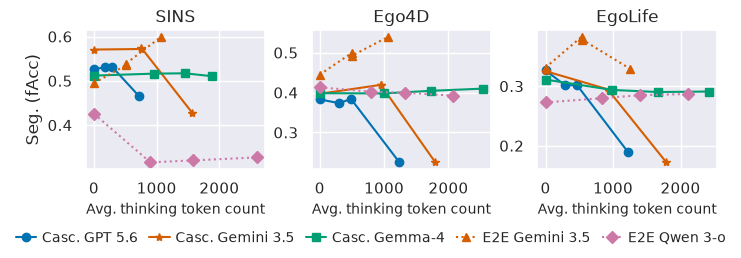

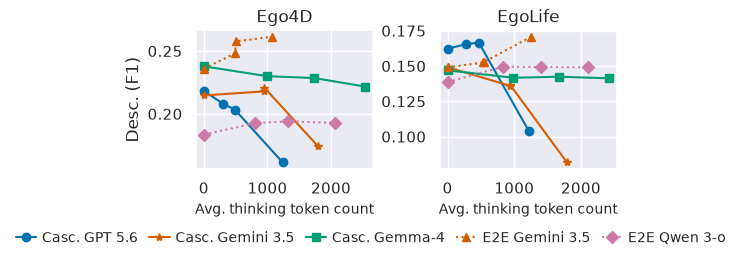

In [8]:
# Thinking ablation — score vs mean(thoughts_tokens) per chunk.
# Matches window-size ablation figure format (cell 33): one figure per metric,
# side-by-side panels per dataset, model legend at bottom. Includes the
# thinking-OFF baseline at x=0 (pulled from desc-v4) so each line shows
# the delta from 'no thinking'.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.style.use('seaborn-v0_8-colorblind')

_thk_family_re = re.compile(r'_thinking(\d+)(?=(?:$|/))')
_lna_family_re = re.compile(r'_reasoning_(low|medium|high)(?=(?:$|/))')

def _family_of(cell):
    for rx in (_thk_family_re, _lna_family_re):
        m = rx.search(cell)
        if m: return cell[:m.start()] + cell[m.end():]
    return None

_thk_by_family = {}
for _cell in _thk_grid.keys():
    fam = _family_of(_cell)
    if fam is None: continue
    _thk_by_family.setdefault(fam, []).append(_cell)

# Mirror window-size cell's model roster + colors/styles for cross-figure consistency.
THK_DISPLAY = {
    'cascB_luna/cascA_af3-hf':          'Casc. GPT 5.6',
    'cascB_gemini/cascA_af3-hf':      'Casc. Gemini 3.5',
    'cascB_gemma4-31b/cascA_af3-hf':    'Casc. Gemma-4',
    # 'cascB_gemma4-31b_ft/cascA_af3-hf': 'Casc. Gemma-4 FT',
    'e2e_gemini':                       'E2E Gemini 3.5',
    'e2e_qwen3-omni':                   'E2E Qwen 3-o',
    # 'e2e_qwen3-omni_ft':              'E2E Qwen 3-o FT',
}
THK_FAMILIES = list(THK_DISPLAY.keys())
THK_STYLE = {
    'cascB_luna/cascA_af3-hf':          dict(color='C0', ls='-',  marker='o'),
    "cascB_gemini/cascA_af3-hf":        dict(color="C2", ls="-", marker="*"),
    'cascB_gemma4-31b/cascA_af3-hf':    dict(color='C1', ls='-',  marker='s'),
    'cascB_gemma4-31b_ft/cascA_af3-hf': dict(color='C1', ls='-',  marker='s'),
    'e2e_gemini':                       dict(color='C2', ls=':', marker='^'),
    'e2e_qwen3-omni':                   dict(color='C3', ls=':', marker='D'),
    'e2e_qwen3-omni_ft':                dict(color='C3', ls=':', marker='D'),
}


def _points_for_family(family, ds, metric):
    """Return (xs, ys) sorted by x. Includes the thinking-OFF baseline at
    x=0 (pulled from the desc-v4 non-thinking run for the same cascade or
    e2e family), so each line shows the delta from 'no thinking' as
    thinking_tokens ramps up."""
    pts = []
    baseline = _desc_v4_metric(family, ds, metric) if '_desc_v4_metric' in globals() else None
    pts.append((0.0, baseline))
    for cell in _thk_by_family.get(family, []):
        slot = _thk_grid.get(cell, {}).get(ds, {})
        x = slot.get('thinking_tokens')
        y = slot.get('F1') if metric == 'descF1' else slot.get(metric)
        if x is not None and y is not None:
            pts.append((x, y))
    pts.sort(key=lambda p: p[0])
    return [p[0] for p in pts], [p[1] for p in pts]


dataset_display = {'sins': 'SINS', 'ego4d': 'Ego4D', 'egolife': 'EgoLife'}

for metric in ['fAcc', 'descF1']:
    meta = {
        'fAcc':   {'title': 'Seg. (fAcc)', 'datasets': ['sins', 'ego4d', 'egolife']},
        'descF1': {'title': 'Desc. (F1)',    'datasets': ['ego4d', 'egolife']},
    }[metric]

    fig, axes = plt.subplots(1, len(meta['datasets']),
                              figsize=(1 + 2 * len(meta['datasets']), 2.5),
                              constrained_layout=True)
    if len(meta['datasets']) == 1:
        axes = [axes]
    for i, (dataset, ax) in enumerate(zip(meta['datasets'], axes)):
        for cell in THK_FAMILIES:
            xs, ys = _points_for_family(cell, dataset, metric)
            if not xs: continue
            ax.plot(xs, ys, label=THK_DISPLAY[cell], **THK_STYLE[cell])

        ax.set_title(dataset_display[dataset])
        ax.set_xlabel('Avg. thinking token count', fontsize=10)
        if i == 0:
            ax.set_ylabel(meta['title'], fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=5, loc='outside lower center',
               frameon=False, fontsize=10, columnspacing=0.8, handletextpad=0.4, handlelength=1.5)
    plt.savefig(f'/tmp/think_{metric}.pdf', bbox_inches='tight')
    plt.show()


In [9]:
# --- Full (CascA x CascB) cascade tables — no averaging over either axis ---

def _cell_metric(ds, mkey):
    """Series of mkey at ds, indexed by (cascA, text_llm) — one entry per cascade cell."""
    sub = df[(df.dataset == ds) & (df.metric == mkey)]
    return sub.set_index(['cascA', 'text_llm'])['value']


def _cell_f1(ds):
    """Per-cell description F1 = 2RP/(R+P) from that cell's own R and P."""
    R = _cell_metric(ds, 'recall')
    P = _cell_metric(ds, 'sprec')
    idx = R.index.union(P.index)
    R = R.reindex(idx); P = P.reindex(idx)
    denom = (R + P).replace(0, np.nan)
    return 2 * R * P / denom


def _full_index():
    """MultiIndex over (CascA, CascB) in the notebook's canonical display order."""
    return pd.MultiIndex.from_tuples(
        [(a, t) for a in CASCA_ORDERED for t in TEXT_LLMS_ORDERED],
        names=['cascA', 'text_llm'],
    )


def _to_display_index(tab):
    """Swap raw arm/model keys for the pretty display names, keep CascA/CascB labels."""
    tab = tab.copy()
    tab.index = pd.MultiIndex.from_tuples(
        [(CASCA_DISPLAY[a], TEXT_LLM_DISPLAY[t]) for a, t in tab.index],
        names=['CascA', 'CascB'],
    )
    return tab


def build_full_ego4d_table():
    ds = 'ego4d'
    cols = pd.MultiIndex.from_tuples([
        ('Seg (Ego4D)',         'bF1'),
        ('Seg (Ego4D)',         'evER↓'),
        ('Seg (Ego4D)',         'fAcc'),
        ('Desc R/P/F1 (Ego4D)', 'R'),
        ('Desc R/P/F1 (Ego4D)', 'P'),
        ('Desc R/P/F1 (Ego4D)', 'F1'),
        ('Desc extras (Ego4D)', 'Hitrate'),
        ('Desc extras (Ego4D)', 'rddc↓'),
    ])
    idx = _full_index()
    data = [
        _cell_metric(ds, 'bF1').reindex(idx),
        _cell_metric(ds, 'EER').reindex(idx),
        _cell_metric(ds, 'facc').reindex(idx),
        _cell_metric(ds, 'recall').reindex(idx),
        _cell_metric(ds, 'sprec').reindex(idx),
        _cell_f1(ds).reindex(idx),
        _cell_metric(ds, 'mrecall').reindex(idx),
        _cell_metric(ds, 'redundant').reindex(idx),
    ]
    tab = pd.DataFrame({c: s.values for c, s in zip(cols, data)}, index=idx)
    tab.columns = cols
    return _to_display_index(tab)


def build_full_sins_egolife_table():
    cols = pd.MultiIndex.from_tuples([
        ('Seg (SINS)',     'bF1'),
        ('Seg (SINS)',     'evER↓'),
        ('Seg (SINS)',     'fAcc'),
        ('Seg (EgoLife)',  'bF1'),
        ('Seg (EgoLife)',  'evER↓'),
        ('Seg (EgoLife)',  'fAcc'),
        ('Desc (EgoLife)', 'R'),
        ('Desc (EgoLife)', 'P'),
        ('Desc (EgoLife)', 'F1'),
    ])
    idx = _full_index()
    data = [
        _cell_metric('sins',    'bF1').reindex(idx),
        _cell_metric('sins',    'EER').reindex(idx),
        _cell_metric('sins',    'facc').reindex(idx),
        _cell_metric('egolife', 'bF1').reindex(idx),
        _cell_metric('egolife', 'EER').reindex(idx),
        _cell_metric('egolife', 'facc').reindex(idx),
        _cell_metric('egolife', 'recall').reindex(idx),
        _cell_metric('egolife', 'sprec').reindex(idx),
        _cell_f1('egolife').reindex(idx),
    ]
    tab = pd.DataFrame({c: s.values for c, s in zip(cols, data)}, index=idx)
    tab.columns = cols
    return _to_display_index(tab)


t_full_ego = build_full_ego4d_table()
t_full_se  = build_full_sins_egolife_table()

print(t_full_ego.to_string())
print(t_full_se.to_string())

                   Seg (Ego4D)                     Desc R/P/F1 (Ego4D)                     Desc extras (Ego4D)          
                           bF1     evER↓      fAcc                   R         P        F1             Hitrate     rddc↓
CascA   CascB                                                                                                           
EnCLAP  K2-V2         0.444911  1.796067  0.189028            0.155879  0.120025  0.135622            0.087114  0.276938
        Olmo 3.1      0.490736  2.918753  0.177120            0.189229  0.150289  0.167526            0.152450  0.343590
        Qwen 2.5      0.481065  2.375157  0.374010            0.238266  0.163279  0.193771            0.176044  0.337003
        Llama 3.3     0.500783  3.829549  0.365893            0.246912  0.148774  0.185673            0.163339  0.382968
        Qwen 3        0.471922  2.779191  0.294039            0.239995  0.163801  0.194709            0.152450  0.372597
        Gemma 4       0.491407  

In [10]:
# --- GT atomic-fact density: loaders -------------------------------------
import json
from pathlib import Path

MANIFESTS = {
    'ego4d':   REPO / "datasets/ego4d/annotated_manifest.json",
    'egolife': REPO / "datasets/egolife/manifest.json",
}
GT_WINDOW_S  = 300.0   # nominal 5-min GT window
WINDOW_TOL_S = 1.0     # keep windows within +/- this of GT_WINDOW_S


def _load_videos(path):
    blob = json.loads(Path(path).read_text())
    vids = blob['videos'] if isinstance(blob, dict) and 'videos' in blob else blob
    return [v for v in vids if isinstance(v, dict)]


def _ego4d_eval_videos(vids, split='test'):
    """Ego4D eval filter: duration >=600s, both passes, >=2 activity runs in pass 1."""
    out = []
    for v in vids:
        if split is not None and v.get('split') != split:
            continue
        ps = v.get('passes') or {}
        if float(v.get('duration', 0)) < 600.0:   continue
        if set(ps) != {'1', '2'}:                 continue
        if len(ps['1'].get('actions') or []) < 2: continue
        out.append(v)
    return out


def _egolife_eval_videos(vids):
    """EgoLife eval filter: duration >=600s, >=2 activity runs (single pass)."""
    return [v for v in vids
            if float(v.get('duration', 0)) >= 600.0
            and len(v['passes']['1'].get('actions') or []) >= 2]


def _fact_windows(video, pass_id='1'):
    """Ego4D stores GT windows under `facts`; EgoLife under `summaries`."""
    p = video['passes'][pass_id]
    return p.get('facts') if 'facts' in p else p.get('summaries') or []


def facts_per_window(videos, pass_id='1', only_5min=True):
    """Long-form frame: one row per GT window, with its atomic-fact count."""
    rows = []
    for v in videos:
        for w in _fact_windows(v, pass_id):
            span = float(w['end']) - float(w['start'])
            if only_5min and abs(span - GT_WINDOW_S) > WINDOW_TOL_S:
                continue
            rows.append({'uid': v['uid'], 'start': float(w['start']),
                         'span_s': span, 'n_facts': len(w.get('facts') or [])})
    return pd.DataFrame(rows)


_ego_vids = _ego4d_eval_videos(_load_videos(MANIFESTS['ego4d']), split='test')
_elf_vids = _egolife_eval_videos(_load_videos(MANIFESTS['egolife']))
print(f'Ego4D test videos: {len(_ego_vids)}   EgoLife sessions: {len(_elf_vids)}')

# --- GT atomic-fact density: summary table --------------------------------
def _describe_facts(fdf, label):
    n = fdf['n_facts']
    return {'group': label, 'n_windows': len(n), 'total_facts': int(n.sum()),
            'mean': n.mean(), 'median': n.median(), 'sd': n.std(),
            'p10': n.quantile(0.10), 'p90': n.quantile(0.90), 'max': int(n.max())}


facts_win = {
    ('ego4d', '1'):   facts_per_window(_ego_vids, '1'),
    ('ego4d', '2'):   facts_per_window(_ego_vids, '2'),
    ('egolife', '1'): facts_per_window(_elf_vids, '1'),
}

facts_summary = pd.DataFrame([
    _describe_facts(facts_win[('ego4d', '1')],   'Ego4D (test) \u00b7 pass 1'),
    _describe_facts(facts_win[('ego4d', '2')],   'Ego4D (test) \u00b7 pass 2'),
    _describe_facts(facts_win[('egolife', '1')], 'EgoLife \u00b7 pass 1'),
]).set_index('group')

print(facts_summary.round(2).to_string())

_e = facts_summary.loc['Ego4D (test) \u00b7 pass 1', 'mean']
_l = facts_summary.loc['EgoLife \u00b7 pass 1', 'mean']
print(f'\nEgoLife / Ego4D fact density ratio: {_l / _e:.1f}x')

print(facts_summary.round(2).to_string())

Ego4D test videos: 163   EgoLife sessions: 170
                       n_windows  total_facts   mean  median     sd   p10   p90  max
group                                                                               
Ego4D (test) · pass 1        986         3586   3.64     3.0   1.31   2.0   5.0   11
Ego4D (test) · pass 2        989         3365   3.40     3.0   1.28   2.0   5.0   15
EgoLife · pass 1            2809       136722  48.67    54.0  16.95  17.0  64.0   78

EgoLife / Ego4D fact density ratio: 13.4x
                       n_windows  total_facts   mean  median     sd   p10   p90  max
group                                                                               
Ego4D (test) · pass 1        986         3586   3.64     3.0   1.31   2.0   5.0   11
Ego4D (test) · pass 2        989         3365   3.40     3.0   1.28   2.0   5.0   15
EgoLife · pass 1            2809       136722  48.67    54.0  16.95  17.0  64.0   78


In [11]:
import glob


def load_predicted_facts(eval_cell_dir):
    """Long-form frame of predicted segments + their AFG atom counts.

    Reads the description-eval AFG cache; one row per predicted segment.
    """
    eval_cell_dir = Path(eval_cell_dir)
    paths = sorted(
        glob.glob(str(eval_cell_dir / "cells" / "*" / "*" / "predicted_facts.json"))
    )
    if not paths:
        raise FileNotFoundError(
            f"no predicted_facts.json under {eval_cell_dir}/cells/*/*/ — "
            "is this an eval_descriptions/<dataset>/<cell> dir?"
        )
    rows = []
    for p in paths:
        blob = json.loads(Path(p).read_text())
        for s in blob.get("segments") or []:
            st, en = float(s["start"]), float(s["end"])
            rows.append(
                {
                    "cell": blob.get("cell"),
                    "uid": blob.get("uid"),
                    "start": st,
                    "end": en,
                    "mid": 0.5 * (st + en),
                    "label": s.get("label"),
                    "n_facts": len(s.get("facts") or []),
                }
            )
    return pd.DataFrame(rows)


def pred_facts_per_window(seg_df, window_s=GT_WINDOW_S):
    """Bin predicted segments into fixed `window_s` windows by midpoint."""
    d = seg_df.copy()
    d["win_idx"] = (d["mid"] // window_s).astype(int)
    g = d.groupby(["uid", "win_idx"], as_index=False).agg(
        n_facts=("n_facts", "sum"), n_segments=("n_facts", "size")
    )
    g["win_start_s"] = g["win_idx"] * window_s
    return g


def print_fact_stats(PRED_EVAL_DIR):
    pred_seg = load_predicted_facts(PRED_EVAL_DIR)
    pred_win = pred_facts_per_window(pred_seg)
    print(
        f"cell={sorted(pred_seg.cell.unique())}  uids={pred_seg.uid.nunique()}  "
        f"segments={len(pred_seg)}  windows={len(pred_win)}"
    )

    # --- Predicted fact density: summary + cross-check ------------------------
    _n, _s = pred_win["n_facts"], pred_seg["n_facts"]
    pred_facts_summary = pd.DataFrame(
        [
            {
                "unit": "per 5-min window",
                "n": len(_n),
                "total_facts": int(_n.sum()),
                "mean": _n.mean(),
                "median": _n.median(),
                "sd": _n.std(),
                "p10": _n.quantile(0.10),
                "p90": _n.quantile(0.90),
                "max": int(_n.max()),
            },
            {
                "unit": "per pred segment",
                "n": len(_s),
                "total_facts": int(_s.sum()),
                "mean": _s.mean(),
                "median": _s.median(),
                "sd": _s.std(),
                "p10": _s.quantile(0.10),
                "p90": _s.quantile(0.90),
                "max": int(_s.max()),
            },
        ]
    ).set_index("unit")
    print(pred_facts_summary.round(2).to_string())


print_fact_stats(
    REPO / "runs/desc-v4-20260715T160821Z/eval_descriptions/ego4d/e2e_qwen3-omni"
)
print_fact_stats(
    REPO / "runs/desc-v4-20260715T160821Z/eval_descriptions/ego4d/e2e_qwen3-omni_ft"
)

cell=['e2e_qwen3-omni']  uids=163  segments=2720  windows=1074
                     n  total_facts  mean  median    sd  p10   p90  max
unit                                                                   
per 5-min window  1074        10443  9.72     6.0  8.00  3.0  20.0   76
per pred segment  2720        10443  3.84     4.0  1.44  2.0   6.0   14
cell=['e2e_qwen3-omni_ft']  uids=163  segments=1489  windows=1044
                     n  total_facts  mean  median    sd  p10  p90  max
unit                                                                  
per 5-min window  1044         4826  4.62     4.0  1.82  3.0  6.0   12
per pred segment  1489         4826  3.24     3.0  0.59  3.0  4.0    7


In [12]:
# --- Number of predicted atomic facts, topline systems (matches paper) ----
# Uses load_predicted_facts / pred_facts_per_window from the cell above.
# Description eval exists only on Ego4D + EgoLife (no SINS GT).

TOPLINE_FACT_ROWS = [
    ('cascB_gemini__cascA_af3-hf',       'Cascaded Gemini 3.5'),
    ('cascB_luna__cascA_af3-hf',         'Cascaded GPT 5.6'),
    ('cascB_gemma4-31b__cascA_af3-hf',   'Cascaded Gemma 4'),
    ('cascB_gemma4-31b_ft__cascA_af3-hf','Cascaded Gemma 4 + SFT'),
    ('e2e_gemini',                       'E2E Gemini 3.5'),
    ('e2e_qwen3-omni',                   'E2E Qwen 3-o'),
    ('e2e_qwen3-omni_ft',                'E2E Qwen 3-o + SFT'),
]
FACT_DATASETS = ['ego4d', 'egolife']


def _pred_fact_stats(cell_name, ds):
    """Return (n_segments, total_facts, facts_per_window_mean, facts_per_seg_mean)."""
    eval_dir = DATA_DIR / 'eval_descriptions' / ds / cell_name
    try:
        seg_df = load_predicted_facts(eval_dir)
    except FileNotFoundError:
        return (float('nan'),) * 4
    if seg_df.empty:
        return (0, 0, float('nan'), float('nan'))
    win_df = pred_facts_per_window(seg_df)
    return (
        len(seg_df),
        int(seg_df['n_facts'].sum()),
        win_df['n_facts'].mean(),
        seg_df['n_facts'].mean(),
    )


_metric_cols = ['n_segments', 'total_facts', 'facts/5-min', 'facts/segment']
_cols = pd.MultiIndex.from_product([FACT_DATASETS, _metric_cols],
                                    names=['dataset', 'metric'])
_rows, _labels = [], []
for cell_name, display in TOPLINE_FACT_ROWS:
    row = []
    for ds in FACT_DATASETS:
        row.extend(_pred_fact_stats(cell_name, ds))
    _rows.append(row)
    _labels.append(display)

# GT reference row (from cell 9's facts_win — pass 1 for both datasets).
_gt_row = []
for ds in FACT_DATASETS:
    gt = facts_win[(ds, '1')]
    _gt_row.extend([
        float('nan'),                        # no "segments" concept for GT
        int(gt['n_facts'].sum()),
        gt['n_facts'].mean(),
        float('nan'),                        # no per-segment mean for GT
    ])
_rows.append(_gt_row)
_labels.append('GT (pass 1, 5-min windows)')

facts_topline = pd.DataFrame(_rows, index=_labels, columns=_cols)
facts_topline.index.name = 'System'

print('=== Topline · predicted atomic-fact counts ===')
print(facts_topline.round(2).to_string(na_rep='—'))

from IPython.display import display, Markdown
display(Markdown('#### Topline · number of predicted atomic facts'))
display(facts_topline.round(2).style.format(na_rep='—', precision=2)
        .set_caption('AFG-extracted atomic facts per topline system. '
                     'GT reference: pass-1 facts summed over 5-min windows. '
                     'SINS omitted — no description GT.'))


=== Topline · predicted atomic-fact counts ===
dataset                         ego4d                                          egolife                                      
metric                     n_segments total_facts facts/5-min facts/segment n_segments total_facts facts/5-min facts/segment
System                                                                                                                      
Cascaded Gemini 3.5            1629.0        8508        9.17          5.22     4383.0       23753        9.21          5.42
Cascaded GPT 5.6               2847.0       16631       18.75          5.84     7599.0       45376       18.94          5.97
Cascaded Gemma 4               2302.0       10074        9.89          4.38     6141.0       28516       10.06          4.64
Cascaded Gemma 4 + SFT         1494.0        4822        4.62          3.23     4366.0       14473        4.91          3.31
E2E Gemini 3.5                 1808.0        6714        8.50          3.71   

#### Topline · number of predicted atomic facts

In [13]:
# --- Event count & duration, topline systems (same set as facts cell) -----
# Uses the SAME preprocessing pipeline as long_audio.eval.metrics.evER:
#   drop_zero_length -> clamp_overlaps -> fill_gaps(PRED_MISSING_LABEL)
#   -> coalesce_runs(key="label")
# So the counts here are guaranteed consistent with the paper's evER numerator.
# GT (actions/annotations) is already coalesced upstream by data-prep.
#
# Rate = total_events / (dataset_audio_seconds / 300), so the denominator is
# shared across all systems in a column.

import sys

from long_audio.eval.metrics import _preprocess_pred, PRED_MISSING_LABEL

EVENT_DATASETS = ['ego4d', 'egolife', 'sins']

SINS_MANIFEST = REPO / "datasets/SINS/manifest.json"
_sins_blob = json.loads(SINS_MANIFEST.read_text())

DATASET_TOTAL_S = {
    'ego4d':   sum(float(v['duration']) for v in _ego_vids),
    'egolife': sum(float(v['duration']) for v in _elf_vids),
    'sins':    float(_sins_blob['duration']),
}

# Per-uid duration lookup (needed by _preprocess_pred).
_UID_DUR = {
    'ego4d':   {v['uid']: float(v['duration']) for v in _ego_vids},
    'egolife': {v['uid']: float(v['duration']) for v in _elf_vids},
    'sins':    {'sins': float(_sins_blob['duration'])},
}


def _sins_cell_dir(cell_name):
    if cell_name.startswith('cascB_') and '__' in cell_name:
        tm, arm = cell_name.split('__', 1)
        return DATA_DIR / tm / arm / 'sins'
    return DATA_DIR / cell_name / 'sins'


def _load_pred_by_uid(cell_name, ds):
    """Return {uid: [{start, end, label}, ...]} for one system-dataset pair.

    Ego4D/EgoLife -> AFG cache (eval_descriptions/<ds>/<cell>/cells/*/*/predicted_facts.json)
    SINS          -> raw chunk_*.json under <system>/sins/
    """
    if ds == 'sins':
        d = _sins_cell_dir(cell_name)
        if not d.is_dir(): return {}
        events = []
        for p in sorted(d.glob('chunk_*.json')):
            blob = json.loads(p.read_text())
            for s in (blob.get('segments_abs') or []):
                events.append({
                    'start': float(s['start']),
                    'end':   float(s['end']),
                    'label': s.get('label'),
                })
        return {'sins': events} if events else {}

    eval_dir = DATA_DIR / 'eval_descriptions' / ds / cell_name
    by_uid = {}
    for p in sorted(eval_dir.glob('cells/*/*/predicted_facts.json')):
        blob = json.loads(p.read_text())
        uid = blob.get('uid')
        for s in (blob.get('segments') or []):
            by_uid.setdefault(uid, []).append({
                'start': float(s['start']),
                'end':   float(s['end']),
                'label': s.get('label'),
            })
    return by_uid


def _pred_event_stats(cell_name, ds):
    """(events/5-min, mean length s) after paper-identical preprocessing."""
    total_evs, total_len = 0, 0.0
    for uid, events in _load_pred_by_uid(cell_name, ds).items():
        dur = _UID_DUR[ds].get(uid)
        if not dur: continue
        prepped, _ = _preprocess_pred(events, dur)
        # Drop the gap-fill sentinel so it doesn't inflate counts.
        real = [e for e in prepped if e['label'] != PRED_MISSING_LABEL]
        total_evs += len(real)
        total_len += sum(e['end'] - e['start'] for e in real)
    if total_evs == 0:
        return (float('nan'), float('nan'))
    rate = total_evs / (DATASET_TOTAL_S[ds] / GT_WINDOW_S)
    return (rate, total_len / total_evs)


def _gt_events(ds):
    """GT is already coalesced upstream; just enumerate."""
    if ds == 'sins':
        return [(float(a['start']), float(a['end']))
                for a in (_sins_blob.get('annotations') or [])]
    vids = _ego_vids if ds == 'ego4d' else _elf_vids
    return [(float(a['start']), float(a['end']))
            for v in vids for a in (v['passes']['1'].get('actions') or [])]


def _gt_stats(ds):
    evs = _gt_events(ds)
    T = DATASET_TOTAL_S[ds]
    if not evs or T <= 0:
        return (float('nan'), float('nan'))
    return (len(evs) / (T / GT_WINDOW_S),
            sum(e - s for s, e in evs) / len(evs))


_evt_cols = pd.MultiIndex.from_product(
    [EVENT_DATASETS, ['events/5-min', 'avg length (s)']],
    names=['dataset', 'metric'],
)

_evt_rows, _evt_labels = [], []
for cell_name, display in TOPLINE_FACT_ROWS:
    row = []
    for ds in EVENT_DATASETS:
        row.extend(_pred_event_stats(cell_name, ds))
    _evt_rows.append(row)
    _evt_labels.append(display)

_gt_row = []
for ds in EVENT_DATASETS:
    _gt_row.extend(_gt_stats(ds))
_evt_rows.append(_gt_row)
_evt_labels.append('GT (annotations / actions)')

events_topline = pd.DataFrame(_evt_rows, index=_evt_labels, columns=_evt_cols)
events_topline.index.name = 'System'

_hrs = {k: v / 3600 for k, v in DATASET_TOTAL_S.items()}
print(f'Audio totals (eval set): '
      f"ego4d={_hrs['ego4d']:.1f}h  egolife={_hrs['egolife']:.1f}h  sins={_hrs['sins']:.1f}h")
print('=== Topline · event count & length (evER-identical preprocessing) ===')
print(events_topline.round(2).to_string(na_rep='—'))

from IPython.display import display, Markdown
display(Markdown('#### Topline · events per 5-min window & avg event length'))
display(events_topline.round(2).style.format(na_rep='—', precision=2)
        .set_caption('Predictions preprocessed identically to the paper\'s evER '
                     'metric (drop-zero-length → clamp-overlaps → fill-gaps → '
                     'coalesce-same-label). Rate = total_events / (dataset_audio / 300s). '
                     'GT rows: Ego4D/EgoLife pass-1 action runs, SINS manifest annotations.'))


Audio totals (eval set): ego4d=82.1h  egolife=240.6h  sins=148.9h
=== Topline · event count & length (evER-identical preprocessing) ===
dataset                           ego4d                     egolife                        sins               
metric                     events/5-min avg length (s) events/5-min avg length (s) events/5-min avg length (s)
System                                                                                                        
Cascaded Gemini 3.5                1.26         235.87         1.12         266.76         0.57         525.00
Cascaded GPT 5.6                   1.51         194.92         1.31         222.68         0.63         473.52
Cascaded Gemma 4                   1.40         213.81         1.17         255.56         0.73         412.33
Cascaded Gemma 4 + SFT             0.30         995.00         0.23        1296.43         0.21        1403.21
E2E Gemini 3.5                     0.66         384.50         0.64         383.66     

#### Topline · events per 5-min window & avg event length

In [14]:
# --- Non-parsable frame rate: thinking runs vs desc-v4 baselines ----------
# pred_missing_rate = fraction of eval-timeline frames the model failed to cover
# (gap-filled with PRED_MISSING_LABEL by _preprocess_pred). Read directly from
# the already-computed eval outputs:
#   Ego4D/EgoLife: eval_segmentation.json -> pred_missing.micro_rate
#   SINS:          summary.json -> eval_scores.frame_level_accuracy.pred_missing_rate

from pathlib import Path

THINKING_ROOTS = [
    REPO / "runs/thinking-20260728T195853Z",
    REPO / "runs/thinking-20260805T011616Z",
]
BASELINE_ROOT = REPO / "runs/desc-v4-20260715T160821Z"

# Non-thinking baseline for each thinking-arm family (naming key -> baseline cell dir).
BASELINE_MAP = {
    'cascB_gemini':      BASELINE_ROOT / 'cascB_gemini'      / 'cascA_af3-hf',
    'cascB_gemma4-31b':  BASELINE_ROOT / 'cascB_gemma4-31b'  / 'cascA_af3-hf',
    'cascB_luna':        BASELINE_ROOT / 'cascB_luna'        / 'cascA_af3-hf',
    'e2e_gemini':        BASELINE_ROOT / 'e2e_gemini',
    'e2e_qwen3-omni':    BASELINE_ROOT / 'e2e_qwen3-omni',
}
THINKING_DATASETS = ['ego4d', 'egolife', 'sins']


def _pred_missing_rate(cell_dir: Path, ds: str):
    if ds == 'sins':
        p = cell_dir / 'sins' / 'summary.json'
        if not p.exists(): return None
        return (json.loads(p.read_text())
                .get('eval_scores', {})
                .get('frame_level_accuracy', {})
                .get('pred_missing_rate'))
    p = cell_dir / ds / 'eval_segmentation.json'
    if not p.exists(): return None
    return (json.loads(p.read_text()).get('pred_missing') or {}).get('micro_rate')


def _baseline_family(arm_name: str):
    """Return the BASELINE_MAP key matching this thinking arm, or None."""
    for family in sorted(BASELINE_MAP, key=len, reverse=True):
        if arm_name.startswith(family):
            return family
    return None


def _iter_thinking_arms():
    for root in THINKING_ROOTS:
        if not root.is_dir(): continue
        for arm_dir in sorted(root.iterdir()):
            if not arm_dir.is_dir() or arm_dir.name.startswith(('eval_', '.')):
                continue
            cascA = next((d for d in arm_dir.iterdir()
                          if d.is_dir() and d.name.startswith('cascA_')), None)
            yield arm_dir.name, (cascA or arm_dir)


rows = []
# 1) Baselines (one row per family, marked as 'baseline').
for family, cell_dir in BASELINE_MAP.items():
    entry = {'family': family, 'variant': 'baseline (no think)', 'arm': family}
    for ds in THINKING_DATASETS:
        entry[ds] = _pred_missing_rate(cell_dir, ds)
    rows.append(entry)

# 2) Thinking arms — group by family so they display next to their baseline.
for arm_name, cell_dir in _iter_thinking_arms():
    family = _baseline_family(arm_name)
    variant = arm_name[len(family):].lstrip('_') if family else arm_name
    entry = {'family': family or arm_name,
             'variant': variant or '(default)',
             'arm': arm_name}
    for ds in THINKING_DATASETS:
        entry[ds] = _pred_missing_rate(cell_dir, ds)
    rows.append(entry)

thinking_missing = (pd.DataFrame(rows)
                    .sort_values(['family', 'variant'])
                    .set_index(['family', 'variant'])
                    [THINKING_DATASETS])

print('=== pred_missing_rate · thinking arms vs desc-v4 baselines ===')
print(thinking_missing
      .map(lambda v: f'{100*v:5.1f}%' if pd.notna(v) else '   —')
      .to_string())

from IPython.display import display, Markdown
display(Markdown('#### Non-parsable frame rate · thinking arms vs baseline'))
display(thinking_missing.style
        .format('{:.1%}', na_rep='—')
        .background_gradient(cmap='Reds', vmin=0.0, vmax=0.5)
        .set_caption('Frame-level pred_missing_rate from the eval outputs. '
                     "Each thinking arm is grouped under its non-thinking "
                     'baseline row (variant="baseline (no think)") from desc-v4.'))


=== pred_missing_rate · thinking arms vs desc-v4 baselines ===
                                       ego4d egolife    sins
family           variant                                    
cascB_gemini     baseline (no think)    0.6%    0.2%    0.0%
                 thinking1024           1.7%    3.0%    0.9%
                 thinking2048           2.4%    2.8%    0.9%
                 thinking4096          49.2%   48.2%   31.1%
cascB_gemma4-31b baseline (no think)    0.4%    0.2%    0.0%
                 thinking1024           2.1%    1.5%    0.7%
                 thinking2048           1.2%    0.5%    0.4%
                 thinking4096           0.5%    0.3%    0.3%
cascB_luna       baseline (no think)    0.5%    0.1%    0.0%
                 reasoning_high        43.1%   38.8%   16.1%
                 reasoning_low          1.3%    0.9%    0.4%
                 reasoning_medium       1.1%    0.4%    0.1%
e2e_gemini       baseline (no think)   15.4%   17.4%    3.4%
                 think

#### Non-parsable frame rate · thinking arms vs baseline

In [15]:
# --- Events per 5-min & avg event length × window size (5 non-SFT arms) ---
# Reuses _preprocess_pred + PRED_MISSING_LABEL from earlier cells.
# 10min baseline reads from desc-v4; other window sizes from ablation-windowsize.

import sys
from long_audio.eval.metrics import _preprocess_pred, PRED_MISSING_LABEL

ABL_ROOT = REPO / "runs/ablation-windowsize"
WINDOW_SIZES = ['5min', '10min', '20min', '30min', '45min']
WIN_DATASETS = ['ego4d', 'egolife', 'sins']

WIN_MODEL_ROWS = [
    ('cascB_gemini/cascA_af3-hf',     'Casc. Gemini 3.5'),
    ('cascB_luna/cascA_af3-hf',       'Casc. GPT 5.6'),
    ('cascB_gemma4-31b/cascA_af3-hf', 'Casc. Gemma 4'),
    ('e2e_gemini',                    'E2E Gemini 3.5'),
    ('e2e_qwen3-omni',                'E2E Qwen 3-o'),
]

# Reuse audio totals + per-uid duration lookups from the events cell.
# (They rely on _ego_vids / _elf_vids / _sins_blob / DATASET_TOTAL_S / _UID_DUR
# which are set in the earlier event-count cell.)


def _win_root(w):
    return DATA_DIR if w == '10min' else ABL_ROOT / w


def _win_sins_dir(root, cell):
    """cell is slash-separated for cascade (e.g. 'cascB_gemini/cascA_af3-hf')."""
    parts = cell.split('/')
    if len(parts) == 2:
        return root / parts[0] / parts[1] / 'sins'
    return root / cell / 'sins'


def _win_load_pred_by_uid(cell, ds, w):
    root = _win_root(w)
    if ds == 'sins':
        d = _win_sins_dir(root, cell)
        if not d.is_dir(): return {}
        events = []
        for p in sorted(d.glob('chunk_*.json')):
            blob = json.loads(p.read_text())
            for s in (blob.get('segments_abs') or []):
                events.append({
                    'start': float(s['start']),
                    'end':   float(s['end']),
                    'label': s.get('label'),
                })
        return {'sins': events} if events else {}
    flat_cell = cell.replace('/', '__')
    eval_dir = root / 'eval_descriptions' / ds / flat_cell
    by_uid = {}
    for p in sorted(eval_dir.glob('cells/*/*/predicted_facts.json')):
        blob = json.loads(p.read_text())
        uid = blob.get('uid')
        for s in (blob.get('segments') or []):
            by_uid.setdefault(uid, []).append({
                'start': float(s['start']),
                'end':   float(s['end']),
                'label': s.get('label'),
            })
    return by_uid


def _win_stats(cell, ds, w):
    total_evs, total_len = 0, 0.0
    for uid, events in _win_load_pred_by_uid(cell, ds, w).items():
        dur = _UID_DUR[ds].get(uid)
        if not dur: continue
        prepped, _ = _preprocess_pred(events, dur)
        real = [e for e in prepped if e['label'] != PRED_MISSING_LABEL]
        total_evs += len(real)
        total_len += sum(e['end'] - e['start'] for e in real)
    if total_evs == 0:
        return (float('nan'), float('nan'))
    return (total_evs / (DATASET_TOTAL_S[ds] / GT_WINDOW_S),
            total_len / total_evs)


# GT rate/length (window-independent — actions / annotations).
_gt_rate_len = {}
for ds in WIN_DATASETS:
    if ds == 'sins':
        evs = [(float(a['start']), float(a['end']))
               for a in (_sins_blob.get('annotations') or [])]
    else:
        vids = _ego_vids if ds == 'ego4d' else _elf_vids
        evs = [(float(a['start']), float(a['end']))
               for v in vids for a in (v['passes']['1'].get('actions') or [])]
    if evs:
        T = DATASET_TOTAL_S[ds]
        _gt_rate_len[ds] = (len(evs) / (T / GT_WINDOW_S),
                            sum(e - s for s, e in evs) / len(evs))
    else:
        _gt_rate_len[ds] = (float('nan'), float('nan'))


_cols = pd.MultiIndex.from_product(
    [['Ego4D', 'EgoLife', 'SINS'], ['Cnt.', 'Len.']],
    names=['dataset', 'metric'],
)

_rows, _idx = [], []
for cell, display in WIN_MODEL_ROWS:
    for w in WINDOW_SIZES:
        row = []
        for ds in WIN_DATASETS:
            row.extend(_win_stats(cell, ds, w))
        _rows.append(row)
        _idx.append((display, w))

# GT row (no window dependency).
_gt_row = []
for ds in WIN_DATASETS:
    _gt_row.extend(_gt_rate_len[ds])
_rows.append(_gt_row)
_idx.append(('GT', '—'))

events_by_window = pd.DataFrame(
    _rows,
    index=pd.MultiIndex.from_tuples(_idx, names=['System', 'Window']),
    columns=_cols,
)

# Format: counts to 2 decimals, lengths to 0 decimals (integer seconds).
def _fmt_cell(v, is_count):
    if pd.isna(v): return '—'
    return f'{v:.2f}' if is_count else f'{v:.0f}'


events_by_window_display = events_by_window.copy().astype(object)
for col in events_by_window.columns:
    is_count = col[1] == 'Cnt.'
    for idx in events_by_window.index:
        events_by_window_display.loc[idx, col] = _fmt_cell(events_by_window.loc[idx, col], is_count)

print('=== Events per 5-min & avg length × window size (5 non-SFT arms) ===')
print(events_by_window_display.to_string())

from IPython.display import display, Markdown
display(Markdown('#### Events per 5-min interval & average event length by window size'))
display(events_by_window.style
        .format({(ds, 'Cnt.'): '{:.2f}' for ds in ['Ego4D', 'EgoLife', 'SINS']}
                | {(ds, 'Len.'): '{:.0f}' for ds in ['Ego4D', 'EgoLife', 'SINS']},
                na_rep='—')
        .set_caption('Non-SFT topline arms swept over inference window size. '
                     'Cnt. = coalesced events per 5-min interval; Len. = mean '
                     'event duration (s). Same _preprocess_pred pipeline as evER; '
                     'GT is window-independent (actions / annotations).'))


=== Events per 5-min & avg length × window size (5 non-SFT arms) ===
dataset                 Ego4D       EgoLife        SINS      
metric                   Cnt.  Len.    Cnt.  Len.  Cnt.  Len.
System           Window                                      
Casc. Gemini 3.5 5min    1.84   162    1.57   191  0.88   341
                 10min   1.26   236    1.12   267  0.57   525
                 20min   1.08   275    0.90   330  0.43   695
                 30min   1.05   282    0.90   332  0.43   697
                 45min   1.05   283    0.90   328  0.46   659
Casc. GPT 5.6    5min    1.89   158    1.58   190  0.87   343
                 10min   1.51   195    1.31   223  0.63   474
                 20min   1.40   211    1.12   268  0.51   588
                 30min   1.31   228    1.10   272  0.43   705
                 45min   1.26   232    0.97   309  0.44   677
Casc. Gemma 4    5min    1.83   164    1.53   196  1.04   289
                 10min   1.40   214    1.17   256  0.73   412
 

#### Events per 5-min interval & average event length by window size